# Notebook 5: RL-DOHO vs standard feature-selection baselines on high-dimensional gene-expression data

**Datasets (5):**
- **Cancer microarrays (scikit-feature benchmarks):** Colon (2,000 genes), ALL/AML (7,129), Lung (3,312, 5 classes) and Glioma (4,434, 4 classes).
- **Rheumatoid arthritis whole blood, GEO GSE93272:** 101 people, one sample per person, the 5,000 most variable probes chosen on each training split.

**Same protocol as Notebooks 2 and 3:**
- 10 seeds, each with a stratified 70/30 split.
- Fitness = 0.99 × (1 − 5-fold CV score of KNN, k=5) + 0.01 × (fraction of features kept). The score is accuracy for the cancer sets and balanced accuracy for GSE93272, as before.
- 20 agents × 50 iterations for every search method.

**Methods compared (11):**
- **DO, HO, DOHO, RL-DOHO:** reused from the saved Notebook 2 and 3 results on Drive if present, otherwise run here.
- **Standard metaheuristics,** with the same encoding, initial population, budget and fitness: **GA** (binary genetic algorithm), **BPSO** (binary particle swarm) and **BGWO** (grey wolf optimizer).
- **Filter / embedded methods:** **LASSO**, **mRMR** and **ReliefF**. Each ranks genes on the training split only, and k is chosen from {5, 10, 20, 50, 100, 200, 500, 1000, 2000, all} by the same CV fitness.
- **All features:** no selection.

**Reported per dataset:**
- fitness, CV score, test accuracy, macro precision, macro recall, macro-F1 and genes selected;
- Friedman test with Holm-corrected Wilcoxon post-hoc tests (RL-DOHO vs each).

**Across datasets:** average ranks, critical-difference diagrams, and each optimiser's own runtime.

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request, gzip
import numpy as np, pandas as pd, scipy.io as sio, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score, recall_score, accuracy_score
from scipy.stats import wilcoxon, friedmanchisquare
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
ROOT     = '/content/drive/MyDrive' if IN_COLAB else '.'
OUT_DIR  = f"{ROOT}/rl_doho_results_baselines_hd"          # results of this notebook
PREV_DIRS = {"cancer": f"{ROOT}/rl_doho_results_hd",       # Notebook 2 (DO/HO/DOHO/RL-DOHO results + fitness caches)
             "ra":     f"{ROOT}/rl_doho_results_ra"}       # Notebook 3 (GSE93272, 5,000 probes)
DATA_DIR = f"{OUT_DIR}/data"
CANCER   = ["colon", "ALLAML", "lung", "GLIOMA"]
DATASETS = CANCER + ["GSE93272"]
SEEDS    = list(range(10))
POP_SIZE, MAX_ITER = 20, 50
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01
N_TOP_RA = 5000                                            # GSE93272: most variable probes per training split
SCORING  = {d: "accuracy" for d in CANCER} | {"GSE93272": "balanced_accuracy"}
STAG_TRIGGER, UCB_C, TABU_TENURE, TIE_EPS = 2, 1.0, None, 0.001   # RL-DOHO settings, unchanged
VERBOSE  = False                                           # True prints every iteration of every run

os.makedirs(DATA_DIR, exist_ok=True)
ALGOS = ["DO", "HO", "DOHO", "RL-DOHO"]; PROPOSED = "RL-DOHO"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR)

Output folder: /content/drive/MyDrive/rl_doho_results_baselines_hd


## 3. Data

In [3]:
DATA = {}
URL = "https://raw.githubusercontent.com/jundongl/scikit-feature/master/skfeature/data/{}.mat"
for name in CANCER:
    path = next((p for p in [f"{PREV_DIRS['cancer']}/data/{name}.mat", f"{DATA_DIR}/{name}.mat"] if os.path.exists(p)), f"{DATA_DIR}/{name}.mat")
    if not os.path.exists(path): urllib.request.urlretrieve(URL.format(name), path)
    d = sio.loadmat(path); DATA[name] = (d["X"].astype(float), d["Y"].ravel())

# GSE93272: one sample per person (first sample of each individual), as in Notebook 3
gpath = next((p for p in [f"{PREV_DIRS['ra']}/data/GSE93272_series_matrix.txt.gz", f"{DATA_DIR}/GSE93272_series_matrix.txt.gz"] if os.path.exists(p)),
             f"{DATA_DIR}/GSE93272_series_matrix.txt.gz")
if not os.path.exists(gpath):
    urllib.request.urlretrieve("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE93nnn/GSE93272/matrix/GSE93272_series_matrix.txt.gz", gpath)
chars = []
with gzip.open(gpath, "rt") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"): gsm = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
        elif line.startswith("!Sample_characteristics_ch1"): chars.append([v.strip('"') for v in line.rstrip("\n").split("\t")[1:]])
        elif line.startswith("!series_matrix_table_begin"): break
    expr = pd.read_csv(f, sep="\t", index_col=0, comment="!")
meta = pd.DataFrame(index=gsm)
for row in chars:
    keys = {v.split(":", 1)[0].strip() for v in row if ":" in v}
    if len(keys) == 1:
        k = keys.pop(); meta[k] = [v.split(":", 1)[1].strip() if ":" in v else None for v in row]
meta["individual id"] = meta.get("individual id", pd.Series(meta.index, index=meta.index)).fillna(pd.Series(meta.index, index=meta.index))
meta_k = meta[~meta["individual id"].duplicated(keep="first")]
DATA["GSE93272"] = (expr[gsm][meta_k.index].T.values.astype(float), (meta_k["disease state"].str.upper() == "RA").astype(int).values)

pd.DataFrame([{"dataset": n, "samples": X.shape[0], "features": X.shape[1], "classes": len(np.unique(y)),
               "class sizes": dict(zip(*[v.tolist() for v in np.unique(y, return_counts=True)]))} for n, (X, y) in DATA.items()])

,dataset,samples,features,classes,class sizes
0,colon,62,2000,2,"{-1: 40, 1: 22}"
1,ALLAML,72,7129,2,"{1: 47, 2: 25}"
2,lung,203,3312,5,"{1: 139, 2: 17, 3: 21, 4: 20, 5: 6}"
3,GLIOMA,50,4434,4,"{1: 14, 2: 7, 3: 14, 4: 15}"
4,GSE93272,101,54613,2,"{0: 35, 1: 66}"


## 4. Fitness function and test evaluation (identical to Notebooks 2 and 3)

In [4]:
COUNTER = {"calls": 0, "new": 0}
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()

def use_dataset(name, seed):
    global X_tr, X_te, y_tr, y_te, N_FEATURES, FEATURES, _cache, CV, CUR, SCORE
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    if name == "GSE93272":
        col_mean = np.nanmean(X_tr, axis=0)
        X_tr = np.where(np.isnan(X_tr), col_mean, X_tr); X_te = np.where(np.isnan(X_te), col_mean, X_te)
        top = np.argsort(X_tr.var(axis=0))[-N_TOP_RA:]; X_tr, X_te = X_tr[:, top], X_te[:, top]
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X_tr.shape[1]; FEATURES = [f"f{i}" for i in range(N_FEATURES)]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed); SCORE = SCORING[name]; CUR = (name, seed)
    _cache = {}
    prev = f"{PREV_DIRS['ra' if name == 'GSE93272' else 'cancer']}/cache_{name}_s{seed}.pkl"   # reuse earlier evaluations
    for cf in (prev, f"{OUT_DIR}/cache_{name}_s{seed}.pkl"):
        if os.path.exists(cf): _cache.update(pickle.load(open(cf, "rb")))

def save_cache(): pass
def save_cache_now(): pickle.dump(_cache, open(f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl", "wb"))

def fitness_function(mask, X_=None, y_=None):
    COUNTER["calls"] += 1
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV, scoring=SCORE).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}; COUNTER["new"] += 1
    if COUNTER["new"] % 50 == 0: print(".", end="", flush=True)
    return f

def test_metrics(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    acc = balanced_accuracy_score(y_te, p) if SCORE == "balanced_accuracy" else accuracy_score(y_te, p)
    return {"test_acc": float(acc), "test_prec": float(precision_score(y_te, p, average="macro", zero_division=0)),
            "test_rec": float(recall_score(y_te, p, average="macro", zero_division=0)), "test_f1": float(f1_score(y_te, p, average="macro"))}

## 5. Helpers and the algorithms (identical code to Notebooks 1–3)

In [5]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def binarize(position): return (sigmoid(position) > 0.5).astype(int)
def mask_disp(m):   # bit string for small problems, a count for high-dimensional ones
    return mask_str(m) if N_FEATURES <= 40 else f"{int(np.sum(m))}/{N_FEATURES} selected"

class IterLogger:
    # Records and prints every iteration of a run.
    def __init__(self, algo, seed, verbose=True):
        self.algo, self.seed, self.verbose = algo, seed, verbose
        self.rows, self.t0, self.seen = [], time.time(), set()
        if verbose:
            print(f"\n{'='*118}\n{algo}  | seed={seed} | pop={POP_SIZE} | iters={MAX_ITER}\n{'='*118}")
            print(f"{'iter':>4} | {'action':<14}| {'best':>7} {'genbest':>7} {'mean':>7} {'worst':>7} | "
                  f"{'#f':>5} | {'best mask':<{min(N_FEATURES, 40) if N_FEATURES <= 40 else 18}} | {'div':>5} | {'new':>3} | {'sec':>5}")

    def log(self, t, action, positions, fitness, best_fit, best_mask, reward=None):
        pm = np.array([binarize(p) for p in positions])
        fresh = {mask_str(m) for m in pm} - self.seen; new = len(fresh); self.seen |= fresh
        row = dict(iter=t, action=action, best=best_fit, gen_best=float(np.min(fitness)),
                   mean=float(np.mean(fitness)), worst=float(np.max(fitness)),
                   n_feats=int(best_mask.sum()), best_mask=best_mask.copy() if N_FEATURES <= 40 else None,
                   pop_masks=pm if N_FEATURES <= 40 else None,
                   diversity=float(np.mean(np.std(positions, axis=0))), new_evals=new,
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = f" r={reward:+.3f}" if reward is not None else ""
            print(f"{t:>4} | {action:<14}| {row['best']:.4f} {row['gen_best']:.4f} {row['mean']:.4f} {row['worst']:.4f} | "
                  f"{row['n_feats']:>5} | {mask_disp(best_mask)} | {row['diversity']:.3f} | {new:>3} | {row['sec']:5.1f}{rw}")
        self.t0 = time.time()

    def finish(self, best_fit, best_mask):
        if self.verbose:
            sel = [FEATURES[i] for i in np.flatnonzero(best_mask)]
            print(f"    ('new' = subsets this run had not evaluated before; {len(self.seen)} distinct subsets in total)")
            print(f"--> {self.algo} done: best fitness={best_fit:.4f}, CV acc={_cache[mask_str(best_mask)]['acc']:.4f}, "
                  f"{len(sel)} features" + (f": {sel}" if len(sel) <= 15 else f" (first 10: {sel[:10]})"))
        save_cache()
        return pd.DataFrame(self.rows)

In [6]:
def _init(rng, dim):
    positions = rng.uniform(-1, 1, size=(POP_SIZE, dim))
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    b = np.argmin(fitness)
    return positions, masks, fitness, positions[b].copy(), masks[b].copy(), fitness[b]

def _evaluate_and_update(positions, fitness, best_position, best_mask, best_fitness, t):
    # Elitism (worst of previous generation gets the best), evaluate, update the global best.
    worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1
    positions[worst_idx] = best_position.copy()
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    g = np.argmin(fitness); improved = fitness[g] < best_fitness
    if improved:
        best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
    return masks, fitness, best_position, best_mask, best_fitness, improved

# ---------------- DO ----------------
def dandelion_optimizer(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "rising" if progress < 0.4 else ("descending" if progress < 0.8 else "landing")
        for i in range(POP_SIZE):
            if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
            elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:                positions[i] += rng.normal(0, 0.1, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, phase, positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- HO ----------------
def hippopotamus_optimization(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("HO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        n_mv = [0, 0, 0]
        for i in range(POP_SIZE):
            r = rng.random()
            if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6; n_mv[0] += 1
            elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i]); n_mv[1] += 1
            else:         positions[i] += rng.normal(0, 0.6, dim); n_mv[2] += 1
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"mv{n_mv[0]}/df{n_mv[1]}/ev{n_mv[2]}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- Fixed DOHO ----------------
def doho_fixed(seed=42, verbose=True, switch_point=0.5):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DOHO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "DO" if progress <= switch_point else "HO"
        for i in range(POP_SIZE):
            if phase == "DO":
                if progress < switch_point * 0.6: positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                else: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"phase {phase}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

In [7]:
# ---------------- Previous RL-DOHO (Q-learning controller, v10): used only in the ablation ----------------
ACTION_NAMES = {0: "DO", 1: "HO", 2: "PERTURB", 3: "RESTART"}

class QLearningController:
    def __init__(self, n_actions=4, alpha=0.5, gamma=0.5, epsilon=0.3, epsilon_decay=0.85, seed=42):
        self.rng = np.random.default_rng(seed); self.q_table = {}
        self.alpha, self.gamma, self.epsilon, self.epsilon_decay, self.n_actions = alpha, gamma, epsilon, epsilon_decay, n_actions
    def get_state(self, positions, stagnation, progress):
        div = np.mean(np.std(positions, axis=0))
        return (int(div >= 0.8), int(stagnation >= 3), int(progress >= 0.5))
    def _q(self, s):
        if s not in self.q_table: self.q_table[s] = np.zeros(self.n_actions)
        return self.q_table[s]
    def choose_action(self, state):
        q = self._q(state)
        if self.rng.random() < self.epsilon: return int(self.rng.integers(0, self.n_actions)), "explore"
        best = np.flatnonzero(q == q.max())                 # random tie-break, not always action 0
        return int(self.rng.choice(best)), "greedy"
    def update(self, s, a, r, s2):
        q = self._q(s); q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])
    def decay_epsilon(self): self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

def rl_doho_qlearning(seed=42, verbose=True, perturb_frac=0.15, controller=None, name="RL-DOHO (Q-learning)"):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = controller(seed) if controller else QLearningController(seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    stagnation = 0; k = max(1, int(round(dim * perturb_frac)))
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        state = agent.get_state(positions, stagnation, progress)
        action, how = agent.choose_action(state)
        order = np.argsort(fitness); worst_half = set(order[POP_SIZE // 2:])
        prev_top = np.mean(np.sort(fitness)[:POP_SIZE // 2]); prev_best = best_fitness
        for i in range(POP_SIZE):
            if action == 0:                                   # DO move
                if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
                else:                positions[i] += rng.normal(0, 0.1, dim)
            elif action == 1:                                 # HO move
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            elif i in worst_half:                             # disruptive actions only hit the worst half
                if action == 2:                               # flip k bits of the best solution
                    p = best_position.copy(); d = rng.choice(dim, k, replace=False)
                    p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); positions[i] = p
                else:                                         # restart
                    positions[i] = rng.uniform(-1, 1, dim)
            else:                                             # good half keeps exploiting
                positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            positions[i] = np.clip(positions[i], -3, 3)
        positions[order[-1]] = best_position.copy()          # elitism
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness:
            best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy(); stagnation = 0
        else:
            stagnation += 1
        new_top = np.mean(np.sort(fitness)[:POP_SIZE // 2])
        reward = 100 * (prev_best - best_fitness) + 10 * (prev_top - new_top)
        agent.update(state, action, reward, agent.get_state(positions, stagnation, min((t + 1) / MAX_ITER, 1.0)))
        agent.decay_epsilon()
        L.log(t, f"{ACTION_NAMES[action]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["rl_action"] = ["init"] + [a.split("(")[0] for a in hist["action"][1:]]
    hist.attrs["q_table"] = {s: q.copy() for s, q in agent.q_table.items()}
    return best_mask, best_fitness, hist

RUNNERS = {"DO": dandelion_optimizer, "HO": hippopotamus_optimization, "DOHO": doho_fixed}

In [8]:
# ---------------- RL-DOHO (proposed): DO + HO + UCB bandit controller ----------------
ARMS = ("PERTURB", "RESTART", "DO", "HO")

class UCBBandit:
    # UCB1 multi-armed bandit (single-state reinforcement learning). Rewards are in [0, 1].
    def __init__(self, n_arms=3, c=1.0, seed=42):
        self.rng = np.random.default_rng(seed); self.c = c
        self.n = np.zeros(n_arms); self.value = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "init"
        ucb = self.value + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "ucb"
    def update(self, arm, r):
        self.n[arm] += 1; self.value[arm] += (r - self.value[arm]) / self.n[arm]

class RandomArm(UCBBandit):              # ablation: same trigger, arm chosen at random
    def choose(self): return int(self.rng.integers(len(self.n))), "random"

class FixedArm(UCBBandit):               # ablation: same trigger, always the same arm
    def __init__(self, arm, seed, n_arms=4): super().__init__(n_arms=n_arms, seed=seed); self.arm = arm
    def choose(self): return self.arm, "fixed"

def _do_move(rng, pos, best_position, progress, dim):
    # DO's movement equations, unchanged
    if progress < 0.4:   pos = pos + rng.normal(0, 1, dim) * (1 - progress)
    elif progress < 0.8: pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.5
    else:                pos = pos + rng.normal(0, 0.1, dim)
    return np.clip(pos, -3, 3)

def _ho_move(rng, pos, best_position, dim):
    # HO's movement equations, unchanged
    r = rng.random()
    if r < 0.5:   pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.6
    elif r < 0.8: pos = pos + rng.uniform(0.2, 0.7) * (best_position - pos)
    else:         pos = pos + rng.normal(0, 0.6, dim)
    return np.clip(pos, -3, 3)

def rl_doho(seed=42, verbose=True, bandit=None, name="RL-DOHO", arms=ARMS, k_max=3, tabu_tries=20, tie_eps=None):
    tie_eps = TIE_EPS if tie_eps is None else tie_eps
    def better(f, nf, bf, bnf):   # strictly better, or a tie within tie_eps with fewer features
        return f < bf - tie_eps or (abs(f - bf) <= tie_eps and (nf < bnf or (nf == bnf and f < bf)))
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = bandit(seed) if bandit else UCBBandit(n_arms=len(arms), c=UCB_C, seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    tabu = {mask_str(m): 0 for m in masks}            # subset -> last iteration it was visited
    def is_tabu(key, t): return key in tabu and (TABU_TENURE is None or t - tabu[key] <= TABU_TENURE)
    def tabu_draw(make, t):
        for _ in range(tabu_tries):
            p = make(); key = mask_str(binarize(p))
            if not is_tabu(key, t): break
        tabu[key] = t                                  # reserve it so two agents don't draw the same subset
        return np.clip(p, -3, 3)
    stagnation = 0

    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        prev_best, prev_median = best_fitness, float(np.median(fitness))
        order = np.argsort(fitness); worst_half = order[POP_SIZE // 2:]
        if stagnation < STAG_TRIGGER:                  # ---- improving: plain DO exploration
            arm, how = None, None
            for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
            touched = np.arange(POP_SIZE)
        else:                                          # ---- stalled: the bandit picks an arm
            arm, how = agent.choose()
            if arms[arm] == "DO":
                for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                touched = np.arange(POP_SIZE)
            elif arms[arm] == "HO":
                for i in range(POP_SIZE): positions[i] = _ho_move(rng, positions[i], best_position, dim)
                touched = np.arange(POP_SIZE)
            else:
                for i in order[:POP_SIZE // 2]:        # better half keeps DO's movement
                    positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                for i in worst_half:
                    if arms[arm] == "PERTURB":     # flip 1..k_max features of the best subset
                        def make():
                            p = best_position.copy(); k = int(rng.integers(1, k_max + 1))
                            d = rng.choice(dim, k, replace=False)
                            p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); return p
                    else:                              # RESTART: fresh random subset
                        make = lambda: rng.uniform(-1, 1, dim)
                    positions[i] = tabu_draw(make, t)
                touched = worst_half
        worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1     # elitism, same rule as DO
        positions[worst_idx] = best_position.copy()
        masks = np.array([binarize(p) for p in positions])
        for m in masks: tabu[mask_str(m)] = t
        fitness = np.array([fitness_function(m) for m in masks])
        improved = False
        for g in np.argsort(fitness):                  # best candidate under the parsimony rule
            if better(fitness[g], masks[g].sum(), best_fitness, best_mask.sum()):
                best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
                improved = True
        stagnation = 0 if improved else stagnation + 1
        if arm is None:
            L.log(t, "DO-explore", positions, fitness, best_fitness, best_mask)
        else:
            # reward: 1 for a new global best, otherwise up to 0.2 for the share of the arm's
            # candidates that beat the previous population median
            touched = [i for i in touched if i != worst_idx]
            share = np.mean([fitness[i] < prev_median for i in touched]) if touched else 0.0
            reward = 1.0 if improved else 0.2 * share
            agent.update(arm, reward)
            L.log(t, f"{arms[arm]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["arm"] = ["init"] + [("EXPLORE" if a == "DO-explore" else a.split("(")[0]) for a in hist["action"][1:]]
    hist.attrs["pulls"] = agent.n.copy(); hist.attrs["arm_value"] = agent.value.copy(); hist.attrs["arm_names"] = list(arms)
    return best_mask, best_fitness, hist

RUNNERS["RL-DOHO"] = rl_doho
print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO']


## 6. Baseline methods

In [9]:
# ================= Baseline metaheuristics =================
# Same encoding (continuous position -> sigmoid > 0.5), same initial population (_init), same population size,
# same number of iterations, and the same fitness function as DO / HO / DOHO / RL-DOHO -> equal evaluation budget.

def genetic_algorithm(seed=42, verbose=True, pc=0.9, tour=3):
    # Binary GA: tournament selection, uniform crossover, bit-flip mutation (rate 1/D), elitism of 1.
    rng = np.random.default_rng(seed); dim = N_FEATURES; pm = 1.0 / dim
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("GA", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        def pick():
            idx = rng.choice(POP_SIZE, tour, replace=False); return masks[idx[np.argmin(fitness[idx])]]
        new = [best_mask.copy()]
        while len(new) < POP_SIZE:
            p1, p2 = pick(), pick()
            if rng.random() < pc:
                cm = rng.random(dim) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
            else:
                kids = [p1.copy(), p2.copy()]
            for c in kids:
                c = np.where(rng.random(dim) < pm, 1 - c, c)
                if len(new) < POP_SIZE: new.append(c)
        masks = np.array(new).astype(int); positions = masks * 2.0 - 1.0
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], masks[g].copy()
        L.log(t, "generation", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

def binary_pso(seed=42, verbose=True, c1=2.0, c2=2.0, vmax=6.0):
    # Binary PSO (Kennedy & Eberhart 1997): sigmoid transfer of velocities, inertia 0.9 -> 0.4.
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    X = masks.copy(); V = rng.uniform(-1, 1, (POP_SIZE, dim))
    pbest, pbest_f = X.copy(), fitness.copy()
    L = IterLogger("BPSO", seed, verbose); L.log(0, "init", X * 2.0 - 1.0, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        w = 0.9 - 0.5 * t / MAX_ITER
        r1, r2 = rng.random((POP_SIZE, dim)), rng.random((POP_SIZE, dim))
        V = np.clip(w * V + c1 * r1 * (pbest - X) + c2 * r2 * (best_mask - X), -vmax, vmax)
        X = (rng.random((POP_SIZE, dim)) < 1 / (1 + np.exp(-V))).astype(int)
        fitness = np.array([fitness_function(m) for m in X])
        imp = fitness < pbest_f; pbest[imp] = X[imp]; pbest_f[imp] = fitness[imp]
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], X[g].copy()
        L.log(t, f"w={w:.2f}", X * 2.0 - 1.0, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

def binary_gwo(seed=42, verbose=True):
    # Grey Wolf Optimizer (Mirjalili et al. 2014) on continuous positions, binarised like DO/HO (sigmoid > 0.5).
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("BGWO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        a = 2 - 2 * t / MAX_ITER
        leaders = positions[np.argsort(fitness)[:3]].copy()
        new = np.empty_like(positions)
        for i in range(POP_SIZE):
            xs = []
            for Lp in leaders:
                A = 2 * a * rng.random(dim) - a; C = 2 * rng.random(dim)
                xs.append(Lp - A * np.abs(C * Lp - positions[i]))
            new[i] = np.clip(np.mean(xs, axis=0), -3, 3)
        positions = new
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness: best_fitness, best_mask = fitness[g], masks[g].copy()
        L.log(t, f"a={a:.2f}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ================= Filter / embedded baselines =================
# Each ranks features on the TRAINING data only; the number of features k is then chosen
# by the same fitness function (CV on training data), so no test data is used.
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

def rank_lasso(X, y, seed, k_max):
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    m = LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=3000, random_state=seed).fit(Xs, y)
    return np.argsort(-np.abs(m.coef_).sum(0), kind="stable")

def rank_mrmr(X, y, seed, k_max):
    # mRMR (difference form): relevance = mutual information with the class; redundancy = mean |correlation| with selected features
    rel = mutual_info_classif(X, y, random_state=seed)
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12); n = len(Xs)
    sel = [int(np.argmax(rel))]; red = np.zeros(X.shape[1])
    for _ in range(min(k_max, X.shape[1], 2000) - 1):        # greedy mRMR up to 2,000 features, then by relevance
        red += np.abs(Xs.T @ Xs[:, sel[-1]]) / n
        score = rel - red / len(sel); score[sel] = -np.inf
        sel.append(int(np.argmax(score)))
    rest = [j for j in np.argsort(-rel) if j not in set(sel)]
    return np.array(sel + rest)

def rank_relieff(X, y, seed, k_max, m=500, k=10):
    # ReliefF (Kononenko 1994) with m sampled instances and k nearest hits/misses per class
    rng = np.random.default_rng(seed)
    Xn = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-12)
    classes, counts = np.unique(y, return_counts=True); prior = dict(zip(classes, counts / len(y)))
    idx = rng.choice(len(Xn), min(m, len(Xn)), replace=False); W = np.zeros(Xn.shape[1])
    for i in idx:
        d = np.abs(Xn - Xn[i]).sum(1); d[i] = np.inf
        for c in classes:
            cand = np.flatnonzero(y == c); cand = cand[cand != i]
            if len(cand) == 0: continue
            nn = cand[np.argsort(d[cand])[:k]]
            diff = np.abs(Xn[nn] - Xn[i]).mean(0)
            if c == y[i]: W -= diff / len(idx)
            else: W += prior[c] / (1 - prior[y[i]]) * diff / len(idx)
    return np.argsort(-W, kind="stable")

RANKERS = {"LASSO": rank_lasso, "mRMR": rank_mrmr, "ReliefF": rank_relieff}

def k_grid(D):
    if D <= 40: return list(range(1, D + 1))
    return sorted({k for k in [5, 10, 20, 50, 100, 200, 500, 1000, 2000, D] if k <= D})

def run_filter(name, seed, X_rank, y_rank):
    # Returns (mask, fitness, chosen k). "All features" keeps everything.
    D = N_FEATURES
    if name == "All features":
        m = np.ones(D, int); return m, fitness_function(m), D
    ks = k_grid(D); order = RANKERS[name](X_rank, y_rank, seed, max(ks))
    best = None
    for k in ks:
        m = np.zeros(D, int); m[order[:k]] = 1
        f = fitness_function(m)
        if best is None or f < best[1] - 1e-12: best = (m, f, k)
    return best

BASELINE_RUNNERS = {"GA": genetic_algorithm, "BPSO": binary_pso, "BGWO": binary_gwo}
FILTERS = ["LASSO", "mRMR", "ReliefF", "All features"]
print("Baselines ready:", list(BASELINE_RUNNERS), "+", FILTERS)

Baselines ready: ['GA', 'BPSO', 'BGWO'] + ['LASSO', 'mRMR', 'ReliefF', 'All features']


## 7. Benchmark: 5 datasets × 10 seeds × 11 methods (resumable)
DO / HO / DOHO / RL-DOHO are reused from Notebooks 2–3 where saved. Every run is saved as soon as it finishes; a dot = 50 new fitness evaluations.

In [10]:
SEARCH  = ALGOS + list(BASELINE_RUNNERS)
METHODS = SEARCH + FILTERS
RES_FILE = f"{OUT_DIR}/baselines_hd_runs_p{POP_SIZE}_i{MAX_ITER}.pkl"
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
PREV = {}
for key, folder in PREV_DIRS.items():
    pf = f"{folder}/hd_runs_p{POP_SIZE}_i{MAX_ITER}.pkl"
    if os.path.exists(pf):
        for (ds, a, s), r in pickle.load(open(pf, "rb")).items():
            if ds in DATASETS and a in ALGOS and isinstance(r, dict) and "mask" in r: PREV[(ds, a, s)] = r
print(f"earlier DO/HO/DOHO/RL-DOHO runs found: {len(PREV)} | runs already done in this notebook: {len(runs)}")

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [a for a in METHODS if (ds, a, s) not in runs]
        if not todo: continue
        use_dataset(ds, s)
        for a in todo:
            info = ""
            if a in ALGOS and (ds, a, s) in PREV:
                r = PREV[(ds, a, s)]; m = np.unpackbits(r["mask"])[:r["n"]].astype(int); f = r["fit"]; info = "reused"
            elif a in ALGOS:
                m, f, _ = RUNNERS[a](seed=s, verbose=VERBOSE)
            elif a in BASELINE_RUNNERS:
                m, f, _ = BASELINE_RUNNERS[a](seed=s, verbose=VERBOSE)
            else:
                m, f, k = run_filter(a, s, X_tr, y_tr); info = f"k={k}"
            m = np.asarray(m).astype(int)
            if mask_str(m) not in _cache: fitness_function(m)
            runs[(ds, a, s)] = {"fit": float(f), "cv": _cache[mask_str(m)]["acc"], "n_feats": int(m.sum()), "info": info, **test_metrics(m)}
            pickle.dump(runs, open(RES_FILE, "wb"))
        save_cache_now()
        print(f"\n[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " +
              "  ".join(f"{a}={runs[(ds, a, s)]['fit']:.4f}" for a in METHODS) + f"   elapsed {time.time() - t_start:.0f}s", flush=True)
print("\nBenchmark complete.")

earlier DO/HO/DOHO/RL-DOHO runs found: 200 | runs already done in this notebook: 0
................................................
[06:31:48] colon seed 0: DO=0.1892  HO=0.1920  DOHO=0.1671  RL-DOHO=0.1667  GA=0.1913  BPSO=0.1670  BGWO=0.1892  LASSO=0.0496  mRMR=0.1404  ReliefF=0.0936  All features=0.3125   elapsed 55s
...............................................
[06:32:40] colon seed 1: DO=0.1175  HO=0.0955  DOHO=0.0735  RL-DOHO=0.1174  GA=0.1639  BPSO=0.0956  BGWO=0.1419  LASSO=0.0221  mRMR=0.0661  ReliefF=0.1158  All features=0.1915   elapsed 107s
................................................
[06:33:33] colon seed 2: DO=0.1671  HO=0.1423  DOHO=0.1671  RL-DOHO=0.1424  GA=0.1640  BPSO=0.1423  BGWO=0.1422  LASSO=0.0220  mRMR=0.0938  ReliefF=0.0720  All features=0.2878   elapsed 159s
................................................
[06:34:25] colon seed 3: DO=0.1919  HO=0.1918  DOHO=0.1918  RL-DOHO=0.1697  GA=0.1474  BPSO=0.1698  BGWO=0.1913  LASSO=0.0496  mRMR=0.1160  ReliefF=0.

## 8. Results per dataset (mean over 10 seeds)

In [11]:
res = pd.DataFrame([{"dataset": ds, "method": a, "seed": s, **r} for (ds, a, s), r in runs.items()
                    if ds in DATASETS and a in METHODS and s in SEEDS])
res.to_csv(f"{OUT_DIR}/baselines_hd_per_run.csv", index=False)
res["rank_fit"] = res.groupby(["dataset", "seed"])["fit"].rank()
res["rank_acc"] = res.groupby(["dataset", "seed"])["test_acc"].rank(ascending=False)
cols = ["fit", "cv", "test_acc", "test_prec", "test_rec", "test_f1", "n_feats", "rank_fit", "rank_acc"]
for ds in DATASETS:
    t = res[res.dataset == ds].groupby("method")[cols].mean().sort_values("rank_fit")
    print(f"\n==================== {ds}  (score = {SCORING[ds]}) ====================")
    print(t.round(4).to_string())
res.groupby(["dataset", "method"])[cols].agg(["mean", "std"]).round(4).to_csv(f"{OUT_DIR}/baselines_hd_summary.csv")


==================== colon  (score = accuracy) ====================
                 fit      cv  test_acc  test_prec  test_rec  test_f1  n_feats  rank_fit  rank_acc
method                                                                                           
LASSO         0.0279  0.9719    0.8211     0.8239    0.8048   0.8026     15.5      1.00      2.40
ReliefF       0.0929  0.9064    0.7789     0.7740    0.7506   0.7564     40.5      2.40      4.55
mRMR          0.1044  0.8950    0.8000     0.8075    0.7911   0.7835     82.5      2.90      4.65
BGWO          0.1577  0.8453    0.7316     0.7321    0.7042   0.7050    913.0      5.70      6.85
BPSO          0.1530  0.8503    0.7211     0.7354    0.6899   0.6881    960.1      6.25      7.90
HO            0.1577  0.8456    0.7579     0.7561    0.7339   0.7351    951.3      6.30      5.55
RL-DOHO       0.1617  0.8414    0.7526     0.7542    0.7238   0.7285    929.1      6.45      5.75
GA            0.1710  0.8317    0.7316     0.7335

## 9. Statistics per dataset: Friedman + Holm-corrected Wilcoxon (RL-DOHO vs each)

In [12]:
def holm(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, min(1.0, (m - i) * p[j])); adj[j] = run
    return adj

rows_all = []
for ds in DATASETS:
    for metric, lower in [("fit", True), ("test_acc", False)]:
        P = res[res.dataset == ds].pivot(index="seed", columns="method", values=metric)[METHODS]
        try: fp = friedmanchisquare(*[P[c] for c in METHODS]).pvalue
        except ValueError: fp = np.nan
        others = [c for c in METHODS if c != PROPOSED]; raw, info = [], []
        for c in others:
            d = (P[PROPOSED] - P[c]) * (1 if lower else -1)
            try: p = wilcoxon(P[PROPOSED], P[c], zero_method="zsplit").pvalue
            except ValueError: p = 1.0
            raw.append(p); info.append((c, int(np.sum(d < -1e-12)), int(np.sum(np.abs(d) <= 1e-12)), int(np.sum(d > 1e-12))))
        adj = holm(raw)
        print(f"\n=== {ds} | {metric} | Friedman p={fp:.2e} ===")
        for (c, w, t_, l), p, pa in zip(info, raw, adj):
            print(f"  RL-DOHO vs {c:12s} W/T/L={w}/{t_}/{l}  p={p:.4f}  Holm p={pa:.4f} {'SIGNIFICANT' if pa < 0.05 else ''}")
            rows_all.append({"dataset": ds, "metric": metric, "vs": c, "wins": w, "ties": t_, "losses": l, "p": p, "holm_p": pa})
pd.DataFrame(rows_all).to_csv(f"{OUT_DIR}/baselines_hd_stats.csv", index=False)


=== colon | fit | Friedman p=7.03e-13 ===
  RL-DOHO vs DO           W/T/L=9/1/0  p=0.0039  Holm p=0.0234 SIGNIFICANT
  RL-DOHO vs HO           W/T/L=4/0/6  p=0.9219  Holm p=1.0000 
  RL-DOHO vs DOHO         W/T/L=8/0/2  p=0.1309  Holm p=0.6543 
  RL-DOHO vs GA           W/T/L=5/0/5  p=0.4316  Holm p=1.0000 
  RL-DOHO vs BPSO         W/T/L=5/0/5  p=0.4922  Holm p=1.0000 
  RL-DOHO vs BGWO         W/T/L=4/0/6  p=0.8457  Holm p=1.0000 
  RL-DOHO vs LASSO        W/T/L=0/0/10  p=0.0020  Holm p=0.0195 SIGNIFICANT
  RL-DOHO vs mRMR         W/T/L=0/0/10  p=0.0020  Holm p=0.0195 SIGNIFICANT
  RL-DOHO vs ReliefF      W/T/L=0/0/10  p=0.0020  Holm p=0.0195 SIGNIFICANT
  RL-DOHO vs All features W/T/L=10/0/0  p=0.0020  Holm p=0.0195 SIGNIFICANT

=== colon | test_acc | Friedman p=5.88e-04 ===
  RL-DOHO vs DO           W/T/L=4/5/1  p=0.1250  Holm p=1.0000 
  RL-DOHO vs HO           W/T/L=3/3/4  p=0.7969  Holm p=1.0000 
  RL-DOHO vs DOHO         W/T/L=2/5/3  p=0.9375  Holm p=1.0000 
  RL-DOHO vs GA   

## 10. Across all datasets: average ranks and critical-difference diagrams

Rank of each method on each dataset (mean fitness):
method      DO   HO  DOHO  RL-DOHO    GA  BPSO  BGWO  LASSO  mRMR  ReliefF  All features
dataset                                                                                 
ALLAML     9.0  5.0   8.0     10.0   7.0   6.0   4.0    1.0   2.0      3.0          11.0
GLIOMA    10.0  6.0   9.0      7.0   8.0   5.0   4.0    1.0   2.0      3.0          11.0
GSE93272   7.0  9.0   5.0      6.0  10.0   4.0   8.0    1.0   2.0      3.0          11.0
colon     10.0  5.0   8.0      7.0   9.0   4.0   6.0    1.0   3.0      2.0          11.0
lung      10.0  9.0   6.0      7.0   4.0   3.0   5.0    1.0   2.0      8.0          11.0

Average rank across datasets (fitness):
method
LASSO            1.0
mRMR             2.2
ReliefF          3.8
BPSO             4.4
BGWO             5.4
HO               6.8
DOHO             7.2
RL-DOHO          7.4
GA               7.6
DO               9.2
All features    11.0

Average rank across datasets (test accuracy):

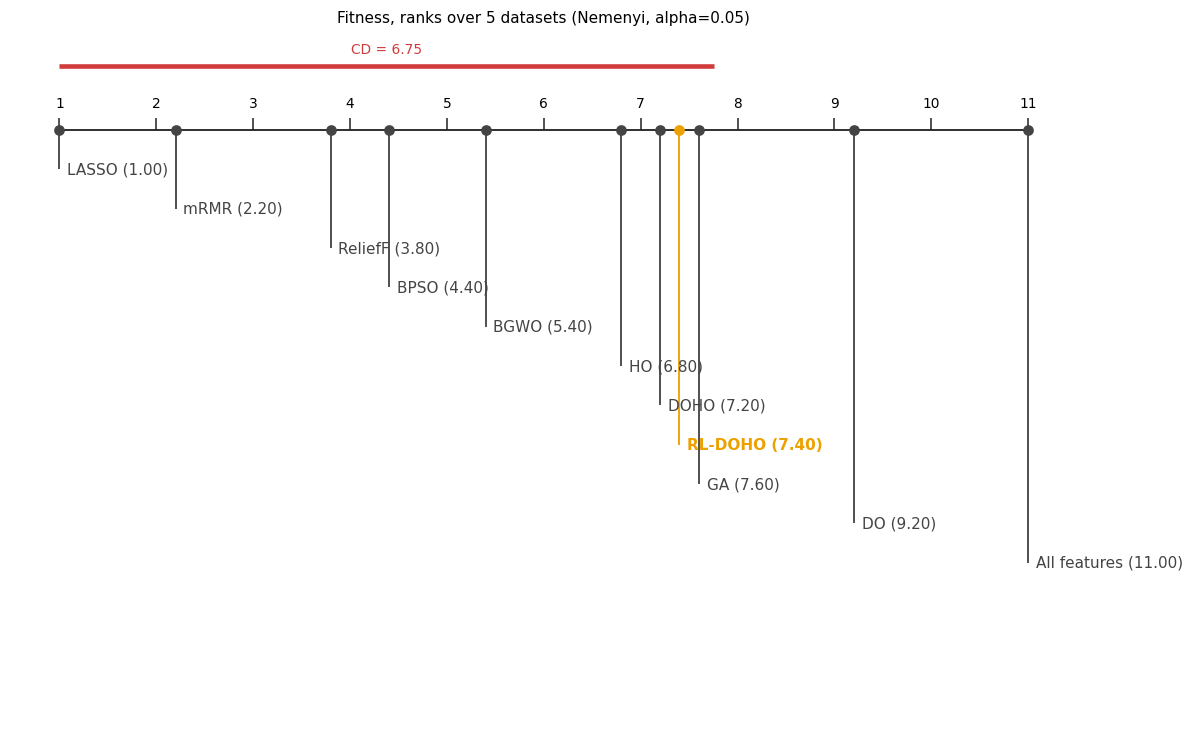

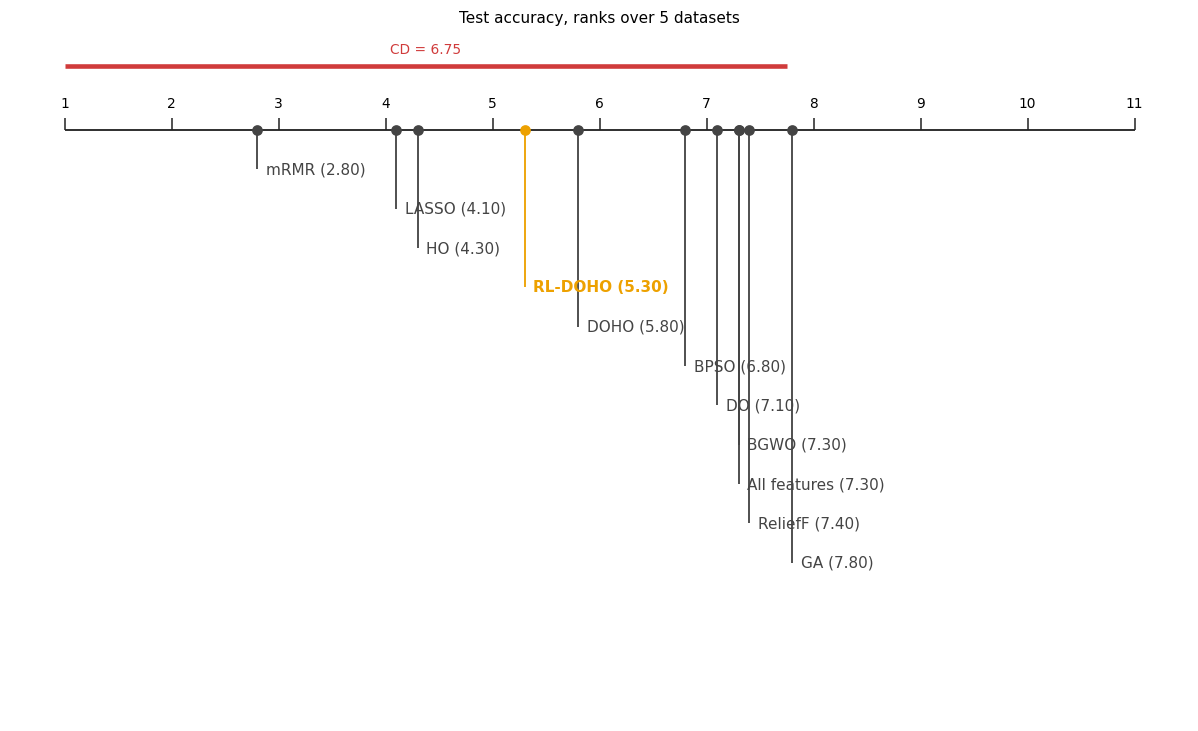

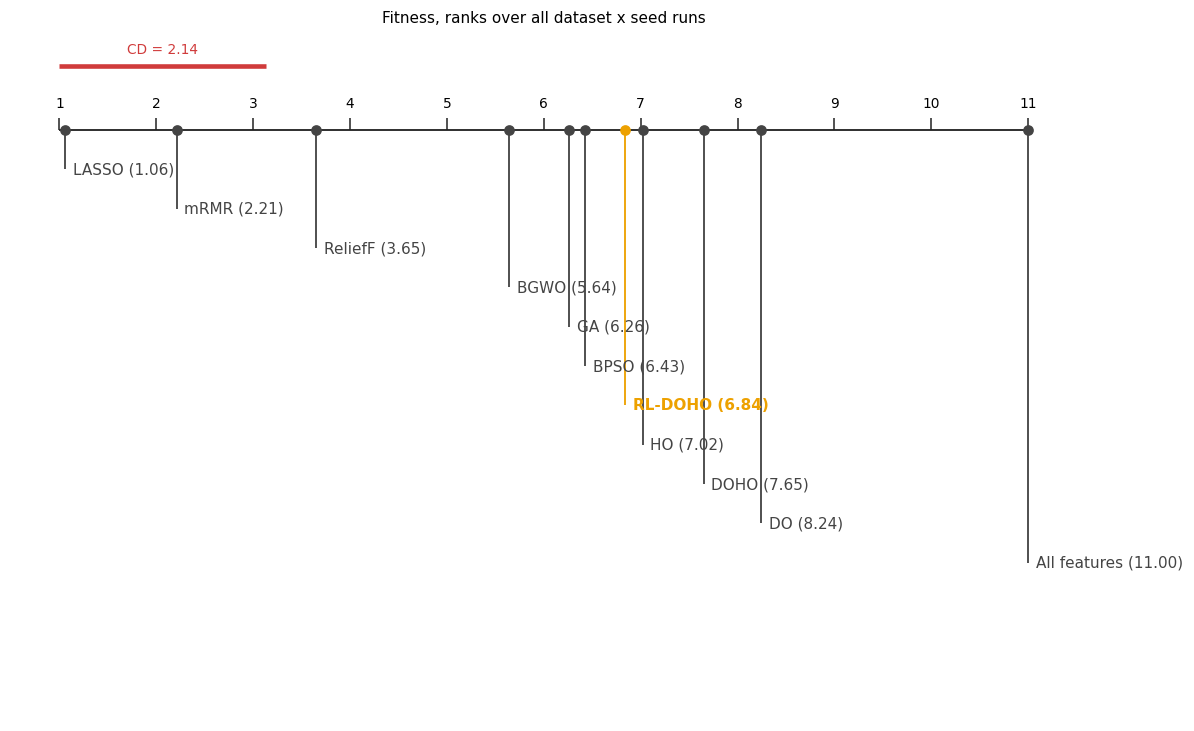

np.float64(2.1352430400308062)

In [13]:
Q05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219, 12: 3.268}
def cd_diagram(avg_ranks, n_blocks, title, fname):
    k = len(avg_ranks); cd = Q05[k] * np.sqrt(k * (k + 1) / (6 * n_blocks)); r = avg_ranks.sort_values()
    fig, ax = plt.subplots(figsize=(11, 0.45 * k + 1.8)); ax.grid(False); ax.axis("off")
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(-k - 1, 2)
    ax.hlines(0, 1, k, color="#222", lw=1.2)
    for x in range(1, k + 1): ax.vlines(x, 0, 0.25, color="#222", lw=1); ax.text(x, 0.45, str(x), ha="center", fontsize=9)
    ax.hlines(1.3, 1, 1 + cd, color="#d03b3b", lw=3); ax.text(1 + cd / 2, 1.55, f"CD = {cd:.2f}", ha="center", color="#d03b3b", fontsize=9)
    for i, (name, v) in enumerate(r.items()):
        y = -(i + 1) * 0.8; col = "#eda100" if name == PROPOSED else "#444"
        ax.vlines(v, y, 0, color=col, lw=1.2); ax.plot(v, 0, "o", color=col, ms=6)
        ax.text(v + 0.08, y, f"{name} ({v:.2f})", va="center", fontsize=10, color=col, fontweight="bold" if name == PROPOSED else None)
    ax.set_title(title, fontsize=10); plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", bbox_inches="tight"); plt.show()
    return cd

# (a) one rank per dataset (mean over seeds), the standard Demsar setup: N = number of datasets
ds_rank_fit = res.groupby(["dataset", "method"])["fit"].mean().unstack()[METHODS].rank(axis=1)
ds_rank_acc = res.groupby(["dataset", "method"])["test_acc"].mean().unstack()[METHODS].rank(axis=1, ascending=False)
print("Rank of each method on each dataset (mean fitness):"); print(ds_rank_fit.round(1).to_string())
print("\nAverage rank across datasets (fitness):"); print(ds_rank_fit.mean().sort_values().round(2).to_string())
print("\nAverage rank across datasets (test accuracy):"); print(ds_rank_acc.mean().sort_values().round(2).to_string())
try: print(f"\nFriedman across datasets (fitness): p={friedmanchisquare(*[ds_rank_fit[c] for c in METHODS]).pvalue:.4f}")
except ValueError: pass
cd_diagram(ds_rank_fit.mean(), len(DATASETS), f"Fitness, ranks over {len(DATASETS)} datasets (Nemenyi, alpha=0.05)", "c1_cd_fitness_datasets.png")
cd_diagram(ds_rank_acc.mean(), len(DATASETS), f"Test accuracy, ranks over {len(DATASETS)} datasets", "c2_cd_acc_datasets.png")
# (b) every dataset x seed as a block (more blocks, narrower CD)
cd_diagram(res.groupby("method")["rank_fit"].mean(), res.groupby(["dataset", "seed"]).ngroups,
           "Fitness, ranks over all dataset x seed runs", "c3_cd_fitness_runs.png")

## 11. Genes selected and optimiser runtime

In [14]:
gsel = res.groupby(["dataset", "method"])["n_feats"].mean().unstack()[METHODS]
print("Mean number of features selected:"); print(gsel.round(0).astype(int).to_string())
use_dataset("colon", 0)

# Optimiser overhead: every method gets the same number of fitness evaluations, so total runtime is dominated by
# model training. To compare the algorithms themselves, time each search method with an instant dummy fitness.
_real_fitness = fitness_function
_dummy_rng = np.random.default_rng(0)
def fitness_function(mask, *a):
    return float(np.sum(mask)) / len(mask) * 0.1 + _dummy_rng.random() * 0.01
over = []
for a in SEARCH:
    fn = RUNNERS.get(a) or BASELINE_RUNNERS[a]
    for s in range(3):
        t0 = time.perf_counter(); fn(seed=s, verbose=False); over.append({"method": a, "ms": 1000 * (time.perf_counter() - t0)})
fitness_function = _real_fitness
overhead = pd.DataFrame(over).groupby("method")["ms"].mean().reindex(SEARCH).round(1)
print("Optimiser overhead per run, excluding fitness evaluations (ms):"); print(overhead.to_string())

print(f"\nAll results, figures and CSVs are in: {OUT_DIR}")

Mean number of features selected:
method      DO    HO  DOHO  RL-DOHO    GA  BPSO  BGWO  LASSO  mRMR  ReliefF  All features
dataset                                                                                  
ALLAML    3475  3464  3470     3448  3347  3477  3358     33   110       56          7129
GLIOMA    2114  2105  2114     2106  2004  2128  2011     18    86       64          4434
GSE93272  2438  2450  2458     2431  2325  2440  2376     48   182      115          5000
colon      960   951   953      929   878   960   913     16    82       40          2000
lung      1584  1579  1574     1578  1477  1602  1496     77   170      645          3312
Optimiser overhead per run, excluding fitness evaluations (ms):
method
DO         262.7
HO         226.5
DOHO       176.7
RL-DOHO    194.6
GA         159.3
BPSO       181.5
BGWO       318.9

All results, figures and CSVs are in: /content/drive/MyDrive/rl_doho_results_baselines_hd
